# Question 16: Which player has the highest winning percentage against top 10 ranked opponents?

Using `event`, `home_team`, and `away_team`

First, we have to find the matches in which the top 10 players are, then find their opponents and after that calculating their winning rate. 

In [28]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

In [2]:
MINI_PROJECT_ROOT = Path.cwd().parents[2]

DATA_ROOT = (
    MINI_PROJECT_ROOT
    / "Tennis Schema"
    / "tennis_data"
)

PROCESSED_ROOT = DATA_ROOT / "processed"

TEAM_DATA_ROOT = DATA_ROOT / "Data"

In [5]:
match_event = pd.read_parquet(TEAM_DATA_ROOT / "event.parquet")
home_team = pd.read_parquet(TEAM_DATA_ROOT / "home_team.parquet")
away_team = pd.read_parquet(TEAM_DATA_ROOT / "away_team.parquet")

print(match_event[["match_id", "winner_code"]].head())

print(home_team[["match_id", "player_id", "full_name", "current_rank"]].head())

print(away_team[["match_id", "player_id", "full_name", "current_rank"]].head())

   match_id  winner_code
0  12011306          NaN
1  12017464          2.0
2  12018812          2.0
3  12021601          1.0
4  12017522          1.0
   match_id  player_id            full_name  current_rank
0  11998445     287803       Cazaux, Arthur          86.0
1  11998445     287803       Cazaux, Arthur          86.0
2  11998446      62790  Lestienne, Constant          99.0
3  11998446      62790  Lestienne, Constant          99.0
4  11998447      64580         Ćorić, Borna          31.0
   match_id  player_id               full_name  current_rank
0  11998445     192013  Auger-Aliassime, Felix          30.0
1  11998445     192013  Auger-Aliassime, Felix          30.0
2  11998446     273680          Flavio Cobolli          69.0
3  11998446     273680          Flavio Cobolli          69.0
4  11998447      77223         Martinez, Pedro         101.0


In [4]:
print("Event:", match_event.shape)
print("Home:", home_team.shape)
print("Away:", away_team.shape)
print("Winner codes:", sorted(match_event["winner_code"].dropna().unique()))

Event: (35053, 12)
Home: (25610, 19)
Away: (24203, 19)
Winner codes: [np.float64(1.0), np.float64(2.0)]


In [7]:
# Keep one final event record per match
match_event_final = (match_event.sort_values(["match_id", "snapshot_date"]).drop_duplicates(subset="match_id", keep="last"))

print("Rows before:", len(match_event))
print("Unique matches:", len(match_event_final))
print(match_event_final[["match_id", "winner_code", "snapshot_date"]].head())

Rows before: 35053
Unique matches: 16873
      match_id  winner_code snapshot_date
1611  11974049          2.0    2024-02-05
415   11974052          2.0    2024-02-03
398   11974053          1.0    2024-02-03
1703  11974065          1.0    2024-02-05
367   11974066          2.0    2024-02-02


In [ ]:
# Keep the latest snapshot of player and ranking record for each match
home_final = (home_team.sort_values(["match_id", "snapshot_date"]).drop_duplicates(subset="match_id", keep="last"))

away_final = (away_team.sort_values(["match_id", "snapshot_date"]).drop_duplicates(subset="match_id", keep="last"))

print("Home unique matches:", len(home_final))
print("Away unique matches:", len(away_final))

print("Home top-10 opponents:", home_final["current_rank"].between(1, 10).sum())
print("Away top-10 opponents:", away_final["current_rank"].between(1, 10).sum())

Home unique matches: 12389
Away unique matches: 11690
Home top-10 opponents: 136
Away top-10 opponents: 103


In [10]:
# Combine match, home player, and away player data
matches = (match_event_final[["match_id", "winner_code"]]
        .merge(
            home_final[["match_id", "player_id", "full_name", "current_rank"]]
            .rename(columns={
                "player_id": "home_player_id",
                "full_name": "home_player",
                "current_rank": "home_rank"}), on="match_id", how="inner")
        .merge(
            away_final[["match_id", "player_id", "full_name", "current_rank"]]
            .rename(columns={
                "player_id": "away_player_id",
                "full_name": "away_player",
                "current_rank": "away_rank"
            }),
            on="match_id",
            how="inner"))

print("Matches available for analysis:", len(matches))

Matches available for analysis: 9882


In [12]:
matches[["match_id", "home_player", "home_rank", "away_player", "away_rank", "winner_code"]].head(10)

,match_id,home_player,home_rank,away_player,away_rank,winner_code
0,11998445,"Cazaux, Arthur",86.0,"Auger-Aliassime, Felix",30.0,2.0
1,11998446,"Lestienne, Constant",99.0,Flavio Cobolli,69.0,2.0
2,11998447,"Ćorić, Borna",31.0,"Martinez, Pedro",101.0,1.0
3,11998448,"Mmoh, Michael",122.0,"Muller, Alexandre",81.0,1.0
4,11998449,"Paire, Benoit",110.0,"Mayot, Harold",132.0,2.0
5,11998450,"Shapovalov, Denis",120.0,"Bublik, Alexander",23.0,2.0
6,11998451,"Shevchenko, Alexander",47.0,"Barrere, Gregoire",124.0,1.0
7,11998452,"Ćorić, Borna",31.0,Flavio Cobolli,69.0,1.0
8,11998453,"Mayot, Harold",132.0,"Auger-Aliassime, Felix",29.0,2.0
9,11998454,"Rune, Holger",7.0,"Mmoh, Michael",122.0,1.0


In [18]:
# Identify matches involving a top-10 ranked opponent
top10_matches = matches[matches["home_rank"].between(1, 10) | matches["away_rank"].between(1, 10)].copy()

top10_matches = top10_matches.sort_values(["home_rank", "away_rank"])

print("Matches involving a top-10 player:", len(top10_matches))

top10_matches[["home_player", "home_rank", "away_player", "away_rank", "winner_code"]].head(10)

Matches involving a top-10 player: 223


,home_player,home_rank,away_player,away_rank,winner_code
1412,"Swiatek, Iga",1.0,"Rybakina, Elena",4.0,1.0
2476,"Swiatek, Iga",1.0,"Zheng, Qinwen",7.0,1.0
4960,"Swiatek, Iga",1.0,"Sakkari, Maria",9.0,1.0
7143,"Swiatek, Iga",1.0,"Alexandrova, Ekaterina",15.0,2.0
1399,"Swiatek, Iga",1.0,"Alexandrova, Ekaterina",17.0,1.0
2470,"Swiatek, Iga",1.0,"Svitolina, Elina",20.0,1.0
1410,"Swiatek, Iga",1.0,"Cirstea, Sorana",22.0,1.0
2473,"Swiatek, Iga",1.0,"Kalinskaya, Anna",24.0,2.0
1417,"Swiatek, Iga",1.0,"Azarenka, Victoria",27.0,1.0
4917,"Swiatek, Iga",1.0,"Noskova, Linda",29.0,1.0


In [ ]:
# Indentify the opponents of the high ranked players

# home palyers
home_vs_top10 = matches[matches["away_rank"].between(1, 10)].copy()
home_vs_top10["player"] = home_vs_top10["home_player"]
home_vs_top10["opponent"] = home_vs_top10["away_player"]
home_vs_top10["opponent_rank"] = home_vs_top10["away_rank"]
home_vs_top10["won"] = home_vs_top10["winner_code"] == 1

# away players
away_vs_top10 = matches[matches["home_rank"].between(1, 10)].copy()
away_vs_top10["player"] = away_vs_top10["away_player"]
away_vs_top10["opponent"] = away_vs_top10["home_player"]
away_vs_top10["opponent_rank"] = away_vs_top10["home_rank"]
away_vs_top10["won"] = away_vs_top10["winner_code"] == 2

vs_top10 = pd.concat([home_vs_top10, away_vs_top10], ignore_index=True)

vs_top10[["player", "opponent", "opponent_rank", "won"]].head(10)

,player,opponent,opponent_rank,won
0,"Haddad Maia, Beatriz","Jabeur, Ons",6.0,True
1,"Raducanu, Emma","Jabeur, Ons",6.0,False
2,"Cirstea, Sorana","Sakkari, Maria",9.0,True
3,"Bielinskyi, Viacheslav","Fritz, Taylor",10.0,False
4,"Krutykh, Oleksii","Fritz, Taylor",10.0,False
5,"Sultanov, Khumoyun","Hurkacz, Hubert",8.0,False
6,"Fomin, Sergey","Hurkacz, Hubert",8.0,False
7,"Orlov, Vladyslav","Fritz, Taylor",10.0,False
8,"Watson, Heather","Ostapenko, Jelena",9.0,False
9,"Sinner, Jannik","de Minaur, Alex",9.0,True


In [25]:
# Calculate each player's win percentage against top-10 opponents
player_stats = (vs_top10.groupby("player").agg(matches_vs_top10=("won", "size"), wins_vs_top10=("won", "sum")))

player_stats["win_percentage"] = (player_stats["wins_vs_top10"] / player_stats["matches_vs_top10"]* 100)
player_stats = player_stats[player_stats["matches_vs_top10"] >= 3]
player_stats = player_stats.sort_values(["win_percentage", "matches_vs_top10"], ascending=[False, False])

player_stats.head(10)

,matches_vs_top10,wins_vs_top10,win_percentage
player,,,
"Humbert, Ugo",3,3,100.000000
"Swiatek, Iga",3,3,100.000000
"Kalinskaya, Anna",5,4,80.000000
"Alcaraz, Carlos",4,3,75.000000
"Sinner, Jannik",4,3,75.000000
"Cirstea, Sorana",3,2,66.666667
"Jarry, Nicolas",3,2,66.666667
"Kostyuk, Marta",3,2,66.666667
"Dimitrov, Grigor",5,3,60.000000


In [26]:
max_win_pct = player_stats["win_percentage"].max()

player_stats[player_stats["win_percentage"] == max_win_pct]

,matches_vs_top10,wins_vs_top10,win_percentage
player,,,
"Humbert, Ugo",3,3,100.0
"Swiatek, Iga",3,3,100.0


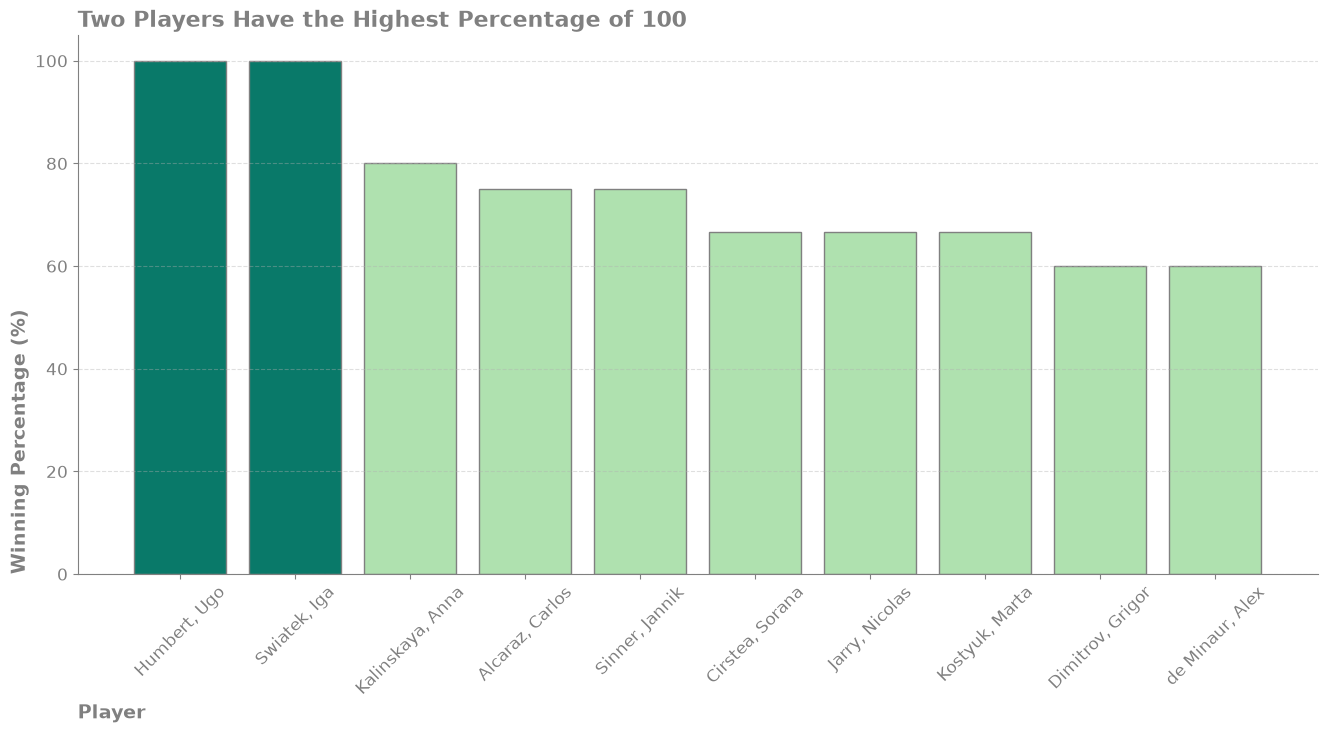

In [35]:
top_10 = player_stats.head(10)

colors = [
    "#097969" if pct == 100 else "#AFE1AF"
    for pct in top_10["win_percentage"]
]

fig, ax = plt.subplots(figsize=(16, 7))

ax.bar(
    top_10.index,
    top_10["win_percentage"],
    color=colors,
    edgecolor="gray"
)

ax.spines[["right", "top"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("gray")

ax.set_title("Two Players Have the Highest Percentage of 100 ", loc="left", weight="bold", color="gray", fontsize=16)
ax.set_xlabel("Player", loc="left", weight="bold", color="gray", fontsize=14)
ax.set_ylabel("Winning Percentage (%)", loc="bottom", weight="bold", color="gray", fontsize=14)

ax.tick_params(axis="x", colors="gray", labelsize="large", rotation=45)
ax.tick_params(axis="y", colors="gray", labelsize="large")

ax.grid(axis="y", linestyle="dashed", alpha=0.4)

ax.set_ylim(0, 105)

plt.show()